# Load Dataset

In [2]:
import numpy as np 
import pandas as pd

import seaborn as sns 
import matplotlib.pyplot as plt  

In [3]:
import easydict 

args = easydict.EasyDict()

args.train_file = "./data/train.csv"
args.test_file = "./data/test.csv"
args.submission_file = "./data/submission.csv"

In [4]:
train = pd.read_csv(args.train_file)
train.shape # (row, columns=features+target)

(916, 12)

In [5]:
test = pd.read_csv(args.test_file)
test.shape # (row, columns=features)

(393, 11)

In [6]:
submission = pd.read_csv(args.submission_file)
submission.shape # (row, columns=ID+target)

(393, 2)

## Target

In [7]:
# 각 class간의 비율 확인 
train['survived'].value_counts() / train.shape[0]

survived
0    0.622271
1    0.377729
Name: count, dtype: float64

# EDA

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  916 non-null    int64  
 1   survived     916 non-null    int64  
 2   pclass       916 non-null    int64  
 3   name         916 non-null    object 
 4   gender       916 non-null    object 
 5   age          736 non-null    float64
 6   sibsp        916 non-null    int64  
 7   parch        916 non-null    int64  
 8   ticket       916 non-null    object 
 9   fare         916 non-null    float64
 10  cabin        198 non-null    object 
 11  embarked     915 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 86.0+ KB


# Data Preprocessing

## data cleaning

In [9]:
# row 중복 제거 
print(f"before: {train.shape}")

# 평가는 학습을 하는 데이터가 아니기 때문에 row 중복 제거 제외
train.drop_duplicates(inplace=True)
print(f"after: {train.shape}")

before: (916, 12)
after: (916, 12)


In [10]:
# 결측치 확인 및 제거 
null_tr = train.isnull().sum()

(null_tr[null_tr > 0] / train.shape[0]).sort_values(ascending=False)

cabin       0.783843
age         0.196507
embarked    0.001092
dtype: float64

In [11]:
print(f"before: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

for tmp in [train, test]:
    null_tmp = tmp.isnull().sum()
    null_cols = null_tmp[null_tmp > 0].index

    for col in null_cols:
        try:
            tmp[col] = tmp[col].fillna(train[col].mean())

        except:
            tmp[col] = tmp[col].fillna(train[col].mode().values[0])

print(f"after: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

before: 899 / 381
after: 0 / 0


In [12]:
train.columns 

Index(['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [13]:
train.set_index(['passengerid'], inplace=True)
test.set_index(['passengerid'], inplace=True)
train.head()

,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
passengerid,,,,,,,,,,,
0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,29.69837,0,0,SC/PARIS 2159,12.8750,B57 B59 B63 B66,S
1,0,3,"Henry, Miss. Delia",female,29.69837,0,0,382649,7.7500,B57 B59 B63 B66,Q
2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.00000,1,1,12749,93.5000,B69,S
3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.00000,0,0,350043,7.7958,B57 B59 B63 B66,S
4,0,2,"Hold, Mr. Stephen",male,44.00000,1,0,26707,26.0000,B57 B59 B63 B66,S


In [14]:
train.columns 

Index(['survived', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch',
       'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [15]:
ticket_counts = pd.concat([train['ticket'], test['ticket']]).value_counts()

train['ticket_group_size'] = train['ticket'].map(ticket_counts)
test['ticket_group_size'] = test['ticket'].map(ticket_counts)

### 새 피처: family_size
- `sibsp`(형제/배우자 수) + `parch`(부모/자녀 수) + 본인 1명 = 같이 탑승한 가족 수.
- 타이타닉에서 자주 쓰이는 파생 피처 — 혼자 탄 사람(1명)이나 대가족(6명 이상)보다 2~4인 소가족의 생존율이 더 높은 비선형 경향이 있어서, `sibsp`/`parch` 원본만 따로 볼 때보다 이 조합이 더 유용한 신호가 될 수 있음.
- 수치형 피처라 `cat_cols`에는 추가하지 않음.

In [16]:
for df in (train, test):
    df['family_size'] = df['sibsp'] + df['parch'] + 1

In [17]:
import re
TITLE_MAP = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs', 'Col': 'Military', 'Major': 'Military', 'Capt': 'Military',
    'Don': 'Noble', 'Dona': 'Noble', 'Sir': 'Noble', 'Lady': 'Noble', 
    'Jonkheer': 'Noble', 'the Countess': 'Noble',
}

def extract_title(name):
    m = re.search(r',\s*([^\.]*)\.', name)
    raw = m.group(1).strip() if m else 'Unknown'
    return TITLE_MAP.get(raw, raw)

for df in (train, test):
    df['title'] = df['name'].apply(extract_title)


In [18]:
cat_cols = ['pclass', 'gender', 'title']

In [19]:
train.drop(['name', 'ticket', 'cabin', 'embarked'], axis=1, inplace=True)
test.drop(['name', 'ticket', 'cabin', 'embarked'], axis=1, inplace=True)

In [20]:
cat_cols = [
    'pclass', 'gender', 'title'
]

# Modeling

In [21]:
from common.modeling import Modeling

## Check Dataset before Modeling

In [22]:
modeling = Modeling(
    x_tr=train.drop(['survived'], axis=1),
    y_tr=train['survived'],
    cat_cols=cat_cols
)

In [23]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

modeling.fit_evaluation(
    x_te = train.drop(['survived'], axis=1),
    y_te = train['survived']
)

training..:   0%|          | 0/3 [00:00<?, ?it/s]

In [24]:
modeling.get_best_model()

{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...),
 'model_name': 'XGBClassifier',
 'hpo': {'tree_method': 'hist', 'enable_categorical': True},
 'train_score': 0.9562873947875469,
 'test_score': 0.9562873947875469,
 'score_type': 'get_auc_score'}

### 디버그: 진짜 에러 확인용
`common/modeling.py`의 예외처리가 버그가 있어서(`.__class__.__name__`이 항상 `type`을 출력) 진짜 에러 내용이 안 보임. Modeling 내부와 똑같은 방식으로 직접 학습시켜서 실제 예외를 확인.

In [25]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

_x_tr = train.drop(['survived'], axis=1).copy()
_y_tr = train['survived']

# Modeling 내부(__convert_dtype)와 동일하게 직접 변환
_bool_cols = _x_tr.select_dtypes(include=['bool', 'boolean']).columns
_x_tr[_bool_cols] = _x_tr[_bool_cols].astype('int8')
_x_tr[cat_cols] = _x_tr[cat_cols].astype('category')

for _name, _cls, _kw in [
    ('xgb', XGBClassifier, {'tree_method': 'hist', 'enable_categorical': True}),
    ('lgb', LGBMClassifier, {'verbose': -1}),
    ('cat', CatBoostClassifier, {'verbose': 0, 'cat_features': cat_cols}),
]:
    try:
        _m = _cls(**_kw)
        _m.fit(_x_tr, _y_tr)
        print(_name, 'OK')
    except Exception as _e:
        print(_name, 'FAILED:', repr(_e))


xgb OK
lgb OK
cat OK


# Evaluation

In [26]:
print(
    f"훈련용 평가지표: {modeling.get_best_model()['train_score']} / 테스트용 평가지표: {modeling.get_best_model()['test_score']}"
)

훈련용 평가지표: 0.9562873947875469 / 테스트용 평가지표: 0.9562873947875469


In [27]:
bool_cols = train.select_dtypes(include=["bool", "boolean"]).columns
train[bool_cols] = train[bool_cols].astype("int8")

train[cat_cols] = train[cat_cols].astype('category')

In [28]:
from common.evaluation_plots import show_norm_conf_mx

pred = modeling.predict_by_best_model(train.drop(['survived'], axis=1))

show_norm_conf_mx(y=train['survived'], pred=pred)

<Figure size 700x500 with 2 Axes>

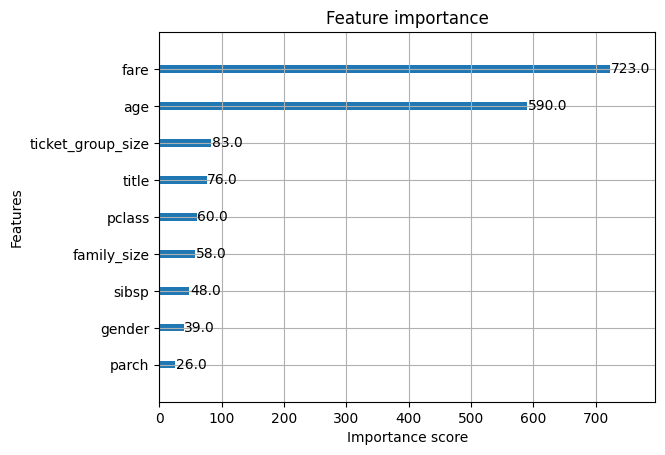

In [29]:
from common.modeling import BoostModelType

BoostModelType.show_plot_importance(modeling.get_best_model()['model'])

# AutoML (PyCaret)
강의안 `4. Auto ML.ipynb` 참고 (PyCaret 사용).

**주의**: PyCaret(`3.3.2`)은 이 프로젝트가 SHAP/XAI 실습용으로 쓰는 NumPy 2 / pandas 3 환경과 맞지 않음. 강의안 안내대로 별도 커널(`.venv-pycaret`, numpy==1.26.4 / pandas==2.1.4 / scipy==1.11.4 / scikit-learn==1.4.2)을 만들어서 이 커널로 바꾼 다음 아래 셀부터 실행해야 함. 기본 프로젝트 커널 그대로 실행하면 import 단계에서 에러 남.

In [30]:
# %pip install "pycaret==3.3.2" "numpy==1.26.4" "pandas==2.1.4" "scipy==1.11.4" "matplotlib==3.7.5" "joblib==1.3.2" "scikit-learn==1.4.2"

In [31]:
import pycaret
pycaret.__version__

'3.3.2'

### PyCaret 셋업

In [32]:
from pycaret.classification import *

exp_clf = setup(data=train, target='survived', session_id=42)

,Description,Value
0,Session id,42
1,Target,survived
2,Target type,Binary
3,Original data shape,"(916, 10)"
4,Transformed data shape,"(916, 19)"
5,Transformed train set shape,"(641, 19)"
6,Transformed test set shape,"(275, 19)"
7,Numeric features,6
8,Categorical features,3
9,Preprocess,True


### 모델 비교 (Stratified 5-Fold, AUC 기준)

In [33]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_automl_model = compare_models(sort='AUC', fold=skf)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8627,0.8939,0.7645,0.8580,0.8078,0.7016,0.7051,0.2580
ridge,Ridge Classifier,0.8658,0.8916,0.7809,0.8524,0.8142,0.7096,0.7121,0.1120
lr,Logistic Regression,0.8658,0.8906,0.7808,0.8517,0.8142,0.7095,0.7116,0.2280
catboost,CatBoost Classifier,0.8689,0.8851,0.7767,0.8639,0.8172,0.7155,0.7188,2.0500
lda,Linear Discriminant Analysis,0.8658,0.8844,0.7809,0.8524,0.8142,0.7096,0.7121,0.0880
lightgbm,Light Gradient Boosting Machine,0.8456,0.8795,0.7397,0.8353,0.7837,0.6643,0.6682,0.1400
nb,Naive Bayes,0.7923,0.8789,0.8509,0.7108,0.7639,0.5866,0.6076,0.0920
rf,Random Forest Classifier,0.8440,0.8789,0.7437,0.8286,0.7831,0.6618,0.6650,0.3620
ada,Ada Boost Classifier,0.8564,0.8777,0.7641,0.8404,0.7996,0.6883,0.6910,0.1900
xgboost,Extreme Gradient Boosting,0.8518,0.8771,0.7562,0.8389,0.7944,0.6790,0.6823,0.1940


### 모델 분석

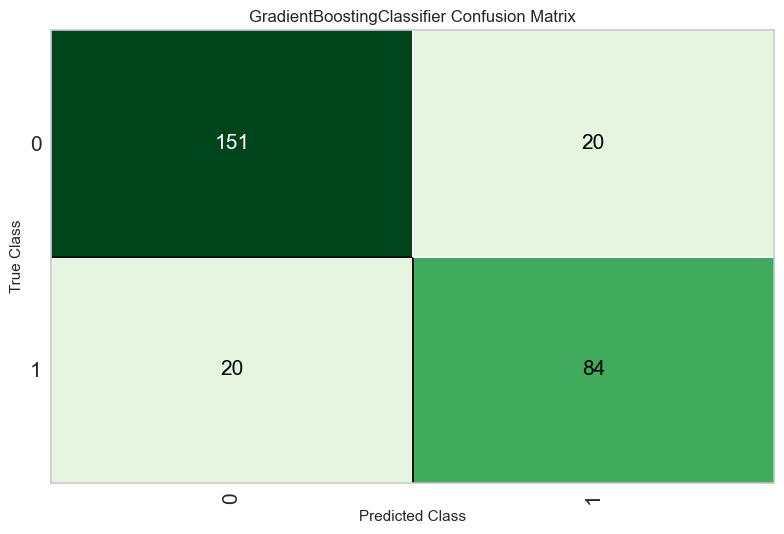

In [34]:
plot_model(best_automl_model, plot='confusion_matrix')

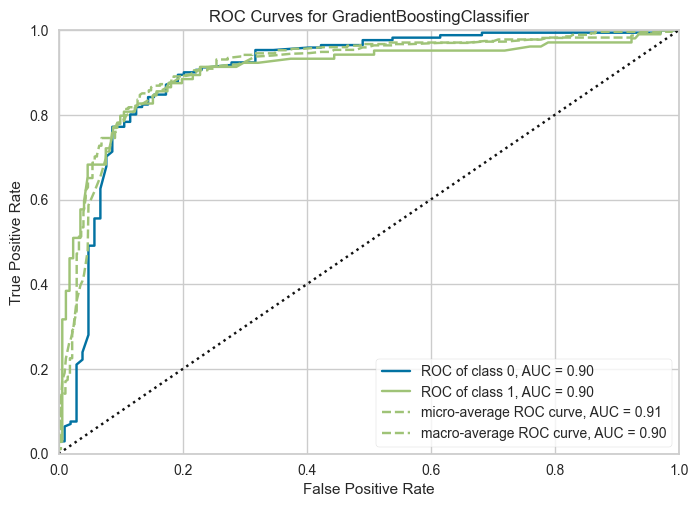

In [35]:
plot_model(best_automl_model, plot='auc')

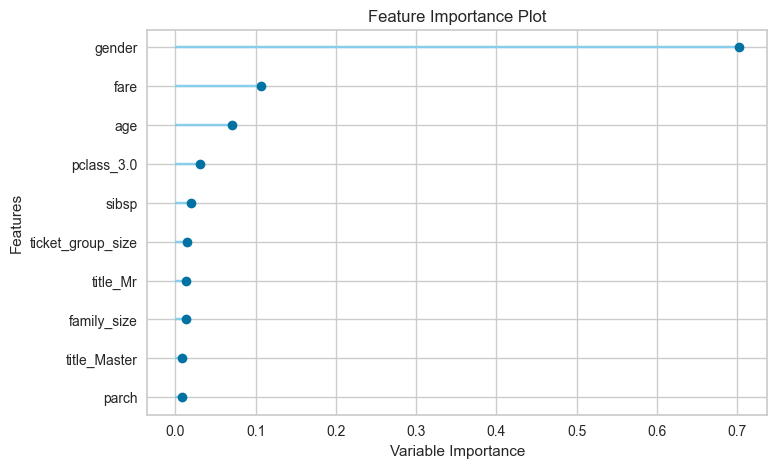

In [36]:
plot_model(best_automl_model, plot='feature')

In [37]:
evaluate_model(best_automl_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### 홀드아웃 예측 확인

In [38]:
holdout_pred = predict_model(best_automl_model)
holdout_pred.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.8545,0.9014,0.8077,0.8077,0.8077,0.6907,0.6907


,pclass,gender,age,sibsp,parch,fare,ticket_group_size,family_size,title,survived,prediction_label,prediction_score
passengerid,,,,,,,,,,,,
774,1,male,43.00000,1,0,27.720800,1,2,Mr,0,0,0.8707
583,3,male,29.69837,8,2,69.550003,11,11,Mr,0,0,0.9499
112,1,female,18.00000,2,2,262.375000,7,5,Miss,1,1,0.9718
118,3,male,44.00000,0,0,7.925000,1,1,Mr,1,0,0.9235
911,3,male,29.69837,1,0,6.437500,1,2,Mr,0,0,0.9670


# Submission

In [39]:
bool_cols = test.select_dtypes(include=["bool", "boolean"]).columns
test[bool_cols] = test[bool_cols].astype("int8")

test[cat_cols] = test[cat_cols].astype('category')


In [40]:
pred = modeling.predict_by_best_model(test)

In [41]:
submission.shape , len(pred)

((393, 2), 393)

In [42]:
submission['survived'] = pred

submission.head()

,passengerid,survived
0,916,1
1,917,1
2,918,1
3,919,0
4,920,1


In [43]:
submission.to_csv("./submission/base_model_0909_01_(9591).csv", index=False)

## AutoML 결과로 제출 (확률 기반)
위 `Modeling` 결과 제출과 별개로, PyCaret이 고른 `best_automl_model`로 테스트셋 예측 후 확률로 제출.
`raw_score=True`로 클래스별 확률(`prediction_score_1` = survived=1일 확률)을 받아서 사용.

In [44]:
test_pred = predict_model(best_automl_model, data=test, raw_score=True)
test_pred.head()

,pclass,gender,age,sibsp,parch,fare,ticket_group_size,family_size,title,prediction_label,prediction_score_0,prediction_score_1
passengerid,,,,,,,,,,,,
916,3,female,15.00000,0,0,8.029200,1,1,Miss,1,0.1970,0.8030
917,2,female,32.00000,0,0,13.000000,1,1,Mrs,1,0.0882,0.9118
918,3,female,29.69837,0,0,7.750000,1,1,Miss,1,0.1776,0.8224
919,3,male,29.69837,0,0,7.250000,1,1,Mr,0,0.9275,0.0725
920,1,female,45.00000,1,1,164.866699,4,3,Mrs,1,0.0550,0.9450


In [45]:
submission['survived'] = test_pred['prediction_score_1'].values
submission.head()

,passengerid,survived
0,916,0.8030
1,917,0.9118
2,918,0.8224
3,919,0.0725
4,920,0.9450


In [47]:
submission.to_csv("./submission/base_model_automl_0912.csv", index=False)